# Volatility Construction and Forecasting Targets

In this notebook I want to construct realized volatility measures, build forecasting targets, engineer volatility features and establish the quantities that future models will attempt to predict.

# Introduction

In Notebook 1 we concluded with these properties:

- Returns are approximately uncorrelated.
- Volatility clusters through time.
- Volatility is persistent.
- Return distributions exhibit fat tails.

The next step is to construct explicit measures of realized volatility. Unlike returns, volatility is not directly observable. Instead, volatility must be estimated using historical price data.

The objective of this notebook is to create:

- Realized volatility estimators
- Forecasting targets
- Volatility features
- Benchmark datasets

These variables will be used throughout.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import yfinance as yf

from scipy.stats import skew
from scipy.stats import kurtosis

plt.style.use("ggplot")

START = "2005-01-01"

In [2]:
spy = yf.download(
    "SPY",
    start=START,
    auto_adjust=True
)

spy["returns"] = np.log(
    spy["Close"] / spy["Close"].shift(1)
)

spy = spy.dropna()

spy.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,returns
Ticker,SPY,SPY,SPY,SPY,SPY,
Date,,,,,,
2005-01-04,80.389252,81.546077,80.125415,81.491955,69167600,-0.012295
2005-01-05,79.834564,80.673431,79.827798,80.328411,65667300,-0.006924
2005-01-06,80.240440,80.605755,80.003664,80.125435,47814700,0.005071
2005-01-07,80.125412,80.659853,79.915692,80.483960,55847700,-0.001435
2005-01-10,80.504280,80.815472,80.057783,80.057783,56563300,0.004717


# Experiment 1: Constructing Realized Volatility

I want to try to measure volatility using historical returns. Now volatility itself cannot be observed directly. Instead, we estimate volatility using the variability of returns.

The most common realized volatility estimator is:

$RV_t = sqrt(252 × Var(r))$

where:

- r represents returns
- 252 annualizes volatility
- RV represents realized volatility

This will be our forecasting target for the remainder.

In [3]:
spy["rv_5"] = (
    spy["returns"]
    .rolling(5)
    .std()
    * np.sqrt(252)
)

spy["rv_10"] = (
    spy["returns"]
    .rolling(10)
    .std()
    * np.sqrt(252)
)

spy["rv_20"] = (
    spy["returns"]
    .rolling(20)
    .std()
    * np.sqrt(252)
)

spy["rv_60"] = (
    spy["returns"]
    .rolling(60)
    .std()
    * np.sqrt(252)
)

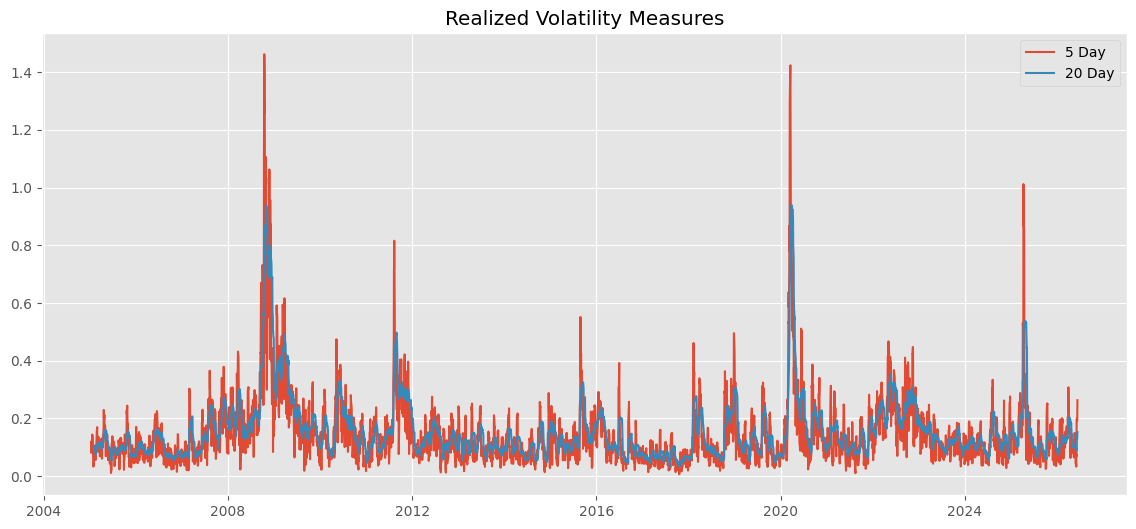

In [4]:
plt.figure(figsize=(14,6))

plt.plot(spy.index, spy["rv_5"], label="5 Day")
plt.plot(spy.index, spy["rv_20"], label="20 Day")

plt.legend()
plt.title("Realized Volatility Measures")

plt.show()

## Comments

Short horizon volatility reacts rapidly to shocks. Longer horizon volatility evolves more smoothly.

This illustrates an important forecasting tradeoff:

- Short horizons are more responsive.
- Long horizons are more stable.

So we must evluate these two situations separately. 


# Experiment 2: Volatility Across Time Horizons

Lets go deeper into these horizons as see how they affect estimation of volatility. 
A cool thing I found out is that risk managers and traders operate on different horizons.

- Options traders focus on short-term volatility.
- Portfolio managers focus on medium-term volatility.
- Pension funds focus on longer horizons.

And these different horizons require different forecasting models.

In [5]:
vol_summary = pd.DataFrame(
    {
        "5D":[spy["rv_5"].mean()],
        "10D":[spy["rv_10"].mean()],
        "20D":[spy["rv_20"].mean()],
        "60D":[spy["rv_60"].mean()]
    }
)

vol_summary

,5D,10D,20D,60D
0,0.147509,0.152877,0.156206,0.162365


## Comments

Volatility estimates differ across horizons because shorter windows react more strongly to recent shocks. This motivates evaluating forecasting models across multiple horizons rather than relying on a single target.

# Experiment 3: Building Forecast Targets

Now lets figure quantity should forecasting models actually predict. 

A forecasting model should not predict today's volatility. Instead, it should predict future volatility. We therefore create forward-looking targets by shifting realized volatility into the future.

In [6]:
spy["target_5d"] = spy["rv_5"].shift(-5)

spy["target_10d"] = spy["rv_10"].shift(-10)

spy["target_20d"] = spy["rv_20"].shift(-20)

In [7]:
spy[
    [
        "rv_20",
        "target_20d"
    ]
].tail()

Price,rv_20,target_20d
Ticker,,
Date,,
2026-06-05,0.132150,NaN
2026-06-08,0.129134,NaN
2026-06-09,0.129300,NaN
2026-06-10,0.140862,NaN
2026-06-11,0.152883,NaN


## Comments

The target variables represent future volatility. Every forecasting model in subsequent notebooks will attempt to predict these quantities using information available today.

# Experiment 4: Absolute Returns

Absolute returns are widely used as a simple measure of market turbulence. Large absolute returns indicate elevated volatility conditions. So they can serve as a volatility proxy

In [8]:
spy["abs_returns"] = np.abs(
    spy["returns"]
)

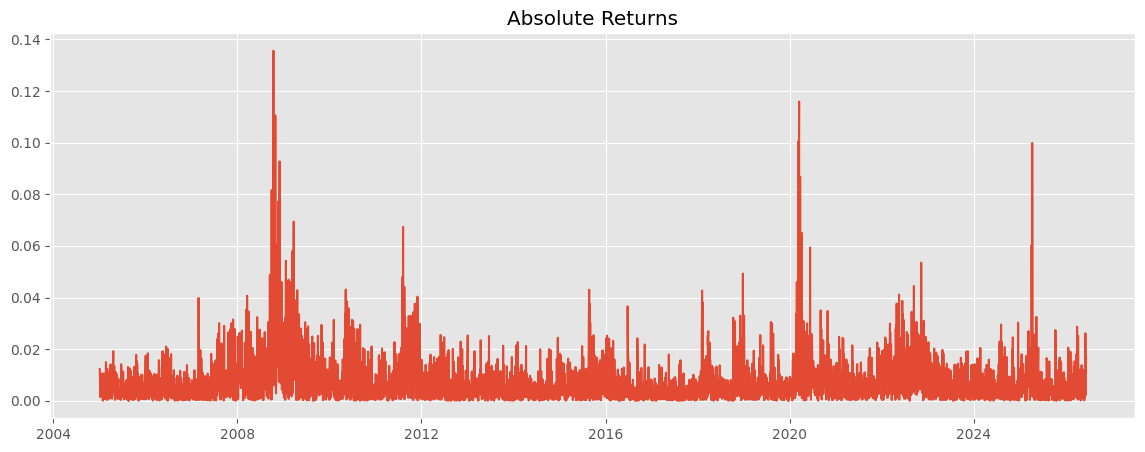

In [9]:
plt.figure(figsize=(14,5))

plt.plot(
    spy.index,
    spy["abs_returns"]
)

plt.title(
    "Absolute Returns"
)

plt.show()

## Comments

Absolute returns exhibit strong clustering behaviour. This suggests that recent market turbulence may contain information about future volatility.

# Experiment 5: Squared Returns

Usually squared returns used in volatility models. Large squared returns indicate periods of elevated risk. These quantities act as observable proxies for latent volatility.

In [10]:
spy["sq_returns"] = (
    spy["returns"]**2
)

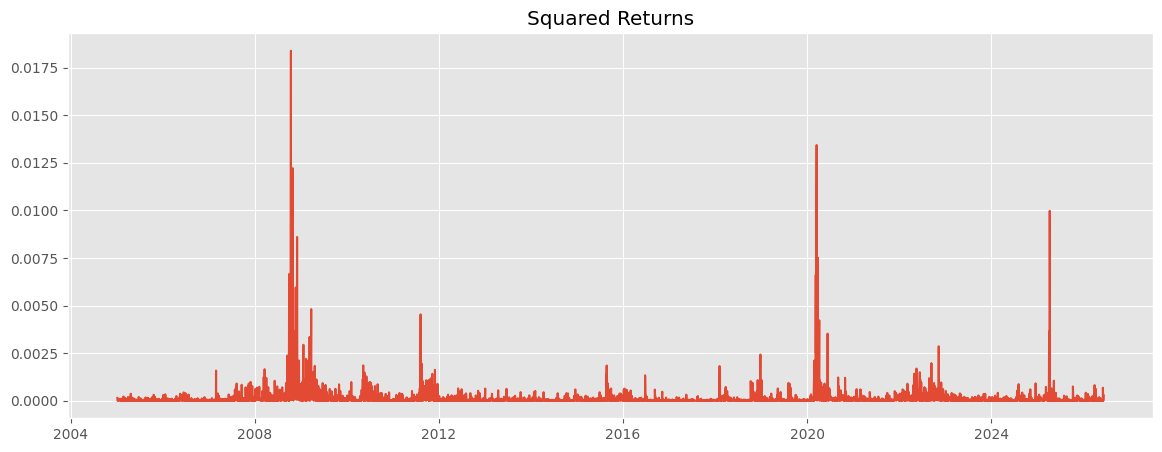

In [11]:
plt.figure(figsize=(14,5))

plt.plot(
    spy.index,
    spy["sq_returns"]
)

plt.title(
    "Squared Returns"
)

plt.show()

## Comments

Volatility bursts become highly visible in the squared return series.

# Experiment 6: Trend Features

Volatility often rises during periods of market stress. Moving averages provide a simple way to characterize market trends.

In [12]:
spy["ma_20"] = (
    spy["Close"]
    .rolling(20)
    .mean()
)

spy["ma_60"] = (
    spy["Close"]
    .rolling(60)
    .mean()
)

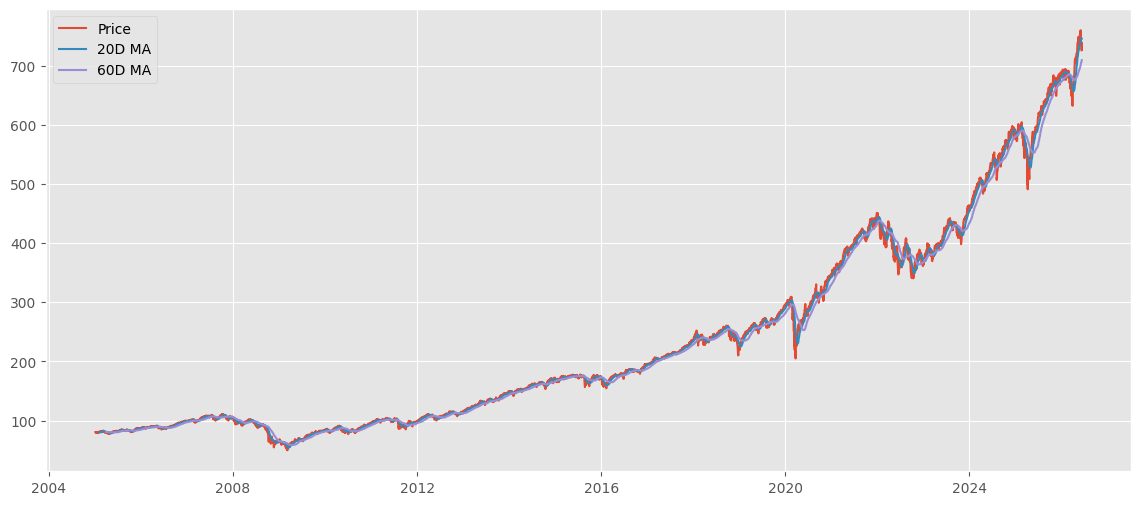

In [13]:
plt.figure(figsize=(14,6))

plt.plot(
    spy.index,
    spy["Close"],
    label="Price"
)

plt.plot(
    spy.index,
    spy["ma_20"],
    label="20D MA"
)

plt.plot(
    spy.index,
    spy["ma_60"],
    label="60D MA"
)

plt.legend()

plt.show()

## Comments

Trend indicators may provide additional context regarding market conditions.
Later models will attempt to determine whether volatility behaves differently under different market environments.

# Experiment 7: Feature Relationships

Before fitting forecasting models, I want to understand relationships between candidate predictors and future volatility targets so I can see which features aappear most related to future volatility

In [14]:
features = spy[
    [
        "abs_returns",
        "sq_returns",
        "rv_5",
        "rv_20",
        "target_20d"
    ]
].dropna()

corr = features.corr()

corr

,Price,abs_returns,sq_returns,rv_5,rv_20,target_20d
,Ticker,,,,,
Price,Ticker,,,,,
abs_returns,,1.000000,0.823402,0.670703,0.562852,0.487991
sq_returns,,0.823402,1.000000,0.586558,0.470538,0.417783
rv_5,,0.670703,0.586558,1.000000,0.821623,0.642601
rv_20,,0.562852,0.470538,0.821623,1.000000,0.648748
target_20d,,0.487991,0.417783,0.642601,0.648748,1.000000


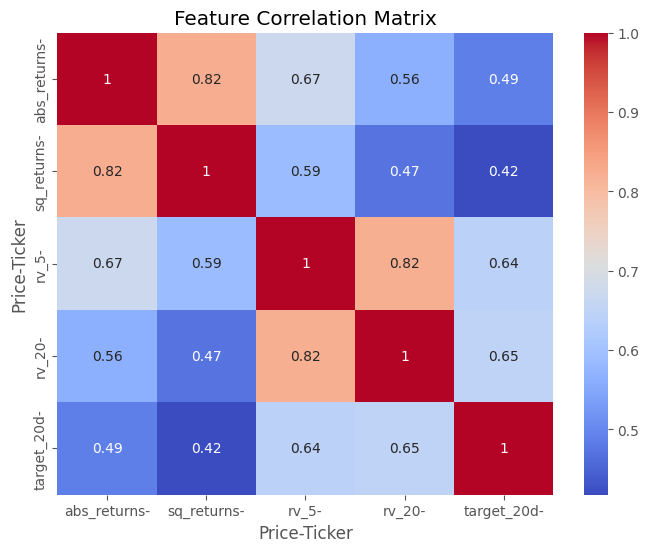

In [15]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Feature Correlation Matrix"
)

plt.show()

## Comments:

Current volatility measures display strong relationships with future volatility. This provides preliminary evidence that volatility is forecastable. If volatility were completely random, these correlations would be close to zero.

# Experiment 8: Building the Forecasting Dataset

Machine learning and econometric models require structured feature matrices. I want combine all engineered features into a single forecasting dataset for model estimation.

In [16]:
dataset = spy[
    [
        "abs_returns",
        "sq_returns",
        "rv_5",
        "rv_10",
        "rv_20",
        "rv_60",
        "target_20d"
    ]
].dropna()

dataset.head()

Price,abs_returns,sq_returns,rv_5,rv_10,rv_20,rv_60,target_20d
Ticker,,,,,,,
Date,,,,,,,
2005-03-31,0.001863,0.000003,0.121891,0.102810,0.108148,0.104172,0.147879
2005-04-01,0.004503,0.000020,0.129649,0.103399,0.108615,0.101517,0.156743
2005-04-04,0.001701,0.000003,0.129778,0.103864,0.096607,0.100587,0.158146
2005-04-05,0.004749,0.000023,0.114159,0.105815,0.099169,0.100520,0.157168
2005-04-06,0.003463,0.000012,0.060798,0.089611,0.100499,0.100721,0.159345


In [20]:
dataset.to_csv("volatility_dataset.csv"
)

From the work so far we can see that volatility is forecastable. In the next notebook we will try to establish the first benchmark forecasting model, Historical Volatility Forecasting.

This benchmark will serve as the baseline against others will be evaluated